# Mix energetico in Europa: nucleare, rinnovabili e fossili

Analisi dell’evoluzione delle fonti di produzione elettrica nei paesi europei, con focus sul confronto tra nucleare, rinnovabili e combustibili fossili nel periodo 1990–2025.

## 1. Fonte dei dati

I dati provengono dall’**Energy Dataset** di [Our World in Data](https://github.com/owid/energy-data), che aggrega e armonizza rilevazioni da fonti istituzionali internazionali — principalmente **Ember** (*Yearly Electricity Data*, copertura sistematica dal 1990 per i paesi europei) e **Energy Institute** (*Statistical Review of World Energy*, serie storiche precedenti). Il dataset è aggiornato al 2026 e rilasciato sotto licenza **CC BY**.

> Ember (2026); Energy Institute - Statistical Review of World Energy (2025) — with major processing by Our World in Data.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd()
df = pd.read_csv(DATA_DIR / "data" / "owid-energy-data.csv")

print(df.shape)
df.head()

(23377, 130)


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [2]:
codebook = pd.read_csv(DATA_DIR / "data" / "owid-energy-codebook.csv")

print(codebook.shape)
codebook.head()

(130, 5)


,column,title,description,unit,source
0,country,Country,Geographic location.,NaN,Our World in Data - Regions (2025)
1,year,Year,Year of observation.,NaN,Our World in Data - Regions (2025)
2,iso_code,ISO code,ISO 3166-1 alpha-3 three-letter country codes.,NaN,International Organization for Standardization...
3,population,Population,"Population by country, available from 10,000 B...",people,Population based on various sources (2024) [ht...
4,gdp,Gross domestic product (GDP),Total economic output of a country or region p...,international-$ in 2011 prices ($),Bolt and van Zanden – Maddison Project Databas...


## 2. Struttura del dataset

Il dataset è in formato **long**: una riga per combinazione di paese e anno, 130 variabili energetiche. Include sia paesi reali che aggregati geografici ed economici costruiti da OWID.

In [3]:
print(f"Righe: {df.shape[0]:,}")
print(f"Colonne: {df.shape[1]}")
print(f"Periodo: {df['year'].min()} - {df['year'].max()}")
print(f"Entità (paesi + aggregati): {df['country'].nunique()}")


Righe: 23,377
Colonne: 130
Periodo: 1900 - 2025
Entità (paesi + aggregati): 314


La colonna `country` contiene anche **aggregati** (continenti, “World”, “EU (Ember)”, “G7 (Ember)” ecc.), riconoscibili dall’assenza di `iso_code`. L’analisi successiva lavora esclusivamente su paesi con codice ISO valido.

In [4]:
# Quante "entità" non sono paesi veri (non hanno iso_code)?
aggregati = sorted(df.loc[df["iso_code"].isna(), "country"].unique())
print(f"Aggregati/non-paesi individuati: {len(aggregati)}")
aggregati[:15]  # primi esempi


Aggregati/non-paesi individuati: 94


['ASEAN (Ember)',
 'Africa',
 'Africa (EI)',
 'Africa (EIA)',
 'Africa (Ember)',
 'Africa (Shift)',
 'Asia',
 'Asia (Ember)',
 'Asia Pacific (EI)',
 'Asia and Oceania (EIA)',
 'Asia and Oceania (Shift)',
 'Australia and New Zealand (EIA)',
 'CIS (EI)',
 'Central America (EI)',
 'Central and South America (EIA)']

## 3. Analisi dei valori mancanti

Il dataset presenta un numero rilevante di `NaN`. Prima di qualsiasi analisi è necessario stabilire se siano **casuali** o **strutturali** — ovvero se la loro distribuzione segua una logica spiegabile da fattori osservabili.

Ogni variabile viene classificata per ciascun paese in quattro pattern: `complete`, `left-censored` (NaN solo prima dell’anno di primo rilevamento), `internal-gaps` (lacune interne alla serie) e `always-null` (nessun dato disponibile). L’analisi è condotta separatamente per l’Europa e per il resto del mondo.

In [5]:
EUROPE_ISO = {
    "ALB", "AND", "AUT", "BLR", "BEL", "BIH", "BGR", "HRV", "CYP", "CZE",
    "DNK", "EST", "FIN", "FRA", "DEU", "GRC", "HUN", "ISL", "IRL", "ITA",
    "XKX", "LVA", "LIE", "LTU", "LUX", "MLT", "MDA", "MCO", "MNE", "NLD",
    "MKD", "NOR", "POL", "PRT", "ROU", "RUS", "SMR", "SRB", "SVK", "SVN",
    "ESP", "SWE", "CHE", "UKR", "GBR", "VAT",
}

KEY_COLS = [
    "electricity_generation",
    "fossil_electricity",
    "nuclear_electricity",
    "renewables_electricity",
    "solar_electricity",
    "wind_electricity",
    "hydro_electricity",
]

df_eu = df[df["iso_code"].isin(EUROPE_ISO)].copy()
print(f"Paesi europei nel dataset: {df_eu['country'].nunique()}")
print(f"Righe totali: {len(df_eu):,}  |  Anni: {df_eu['year'].min()}–{df_eu['year'].max()}")

Paesi europei nel dataset: 40
Righe totali: 3,488  |  Anni: 1900–2025


In [6]:
def classify_missing(series: pd.Series) -> dict:
    first_idx = series.first_valid_index()
    if first_idx is None:
        return {"first_valid": None, "nan_before": int(series.isna().sum()), "nan_after": 0, "pattern": "always-null"}
    nan_before = int(series.loc[:first_idx].iloc[:-1].isna().sum())
    nan_after  = int(series.loc[first_idx:].isna().sum())
    if nan_after == 0:
        pattern = "complete" if nan_before == 0 else "left-censored"
    else:
        pattern = "internal-gaps"
    return {"first_valid": first_idx, "nan_before": nan_before, "nan_after": nan_after, "pattern": pattern}


def gap_ranges(s: pd.Series, first_idx) -> str | None:
    """Restituisce gli anni NaN dopo first_idx come stringa di intervalli, o None se assenti."""
    gap_years = s.loc[first_idx:][s.loc[first_idx:].isna()].index.tolist()
    if not gap_years:
        return None
    ranges, start, prev = [], gap_years[0], gap_years[0]
    for y in gap_years[1:]:
        if y == prev + 1:
            prev = y
        else:
            ranges.append(f"{start}–{prev}" if start != prev else str(start))
            start = prev = y
    ranges.append(f"{start}–{prev}" if start != prev else str(start))
    return ", ".join(ranges)


def build_miss(df_subset: pd.DataFrame) -> pd.DataFrame:
    """Classifica il pattern dei missing values per ogni coppia paese × colonna chiave."""
    records = []
    for country, grp in df_subset.groupby("country"):
        grp_sorted = grp.sort_values("year").set_index("year")
        for col in KEY_COLS:
            if col in grp_sorted.columns:
                records.append({"country": country, "column": col, **classify_missing(grp_sorted[col])})
    return pd.DataFrame(records)


miss = build_miss(df_eu)

### 3.1 Copertura temporale dei paesi europei

In [7]:
print("=== Distribuzione dei pattern — Europa (paese × colonna) ===")
print(miss["pattern"].value_counts().to_string())

print("\n=== Anno del primo dato valido ===")
pivot = miss[miss["pattern"] != "always-null"].pivot(
    index="country", columns="column", values="first_valid"
).astype("Int64")
print(pivot.to_string())

print("\n=== Gap interni ===")
for country, grp in df_eu.groupby("country"):
    grp_sorted = grp.sort_values("year").set_index("year")
    for col in KEY_COLS:
        if col not in grp_sorted.columns:
            continue
        s = grp_sorted[col]
        first_idx = s.first_valid_index()
        if first_idx is None:
            continue
        r = gap_ranges(s, first_idx)
        if r:
            print(f"  {country:30s}  {col:30s}  {r}")

=== Distribuzione dei pattern — Europa (paese × colonna) ===
pattern
left-censored    174
complete          86
internal-gaps     20

=== Anno del primo dato valido ===
column                  electricity_generation  fossil_electricity  hydro_electricity  nuclear_electricity  renewables_electricity  solar_electricity  wind_electricity
country                                                                                                                                                                
Albania                                   2000                2000               2000                 2000                    2000               2000              2000
Austria                                   1985                1990               1965                 1965                    1965               1965              1965
Belarus                                   1985                2000               1985                 1985                    1985               1985           

**Europa — copertura**

Il left-censoring è il pattern dominante (174 coppie paese-colonna), ma il 1990 non è il punto di partenza tipico: il 71% di queste serie inizia *prima* del 1990, con mediana al 1965. La soglia del 1990 vale soprattutto per `fossil_electricity`, dove la maggior parte dei paesi parte effettivamente da quell'anno. Per cinque delle altre sei variabili chiave (nucleare, rinnovabili, solare, eolico, idroelettrico), 25 dei 40 paesi europei hanno dati già dal 1965 grazie alle serie storiche dell'Energy Institute — non un'eccezione limitata a poche grandi economie, ma la norma per la maggior parte dell'Europa occidentale e settentrionale. `electricity_generation` (la generazione totale) fa eccezione e segue invece il pattern di `fossil_electricity`: nessun paese europeo ha un dato di generazione totale prima del 1985 (dettaglio in 3.4). Il 1990 riguarda soprattutto gli ex paesi sovietici e jugoslavi (dati dal 1985 o 1990) e i paesi entrati più tardi nella rilevazione (Albania, Bosnia, Moldova dal 2000; Montenegro dal 2005).

I gap interni si concentrano sui paesi successori dell'URSS e della Jugoslavia — con discontinuità tipicamente tra il 1990 e il 1993. I microstati (Andorra, Monaco, Liechtenstein, San Marino, Vaticano) registrano always-null su variabili come `nuclear_electricity`, fisicamente assente dal loro territorio.

### 3.2 Copertura nel resto del mondo

In [8]:
df_world = df[df["iso_code"].notna() & ~df["iso_code"].isin(EUROPE_ISO)].copy()
print(f"Paesi non europei nel dataset: {df_world['country'].nunique()}")

miss_w = build_miss(df_world)

print("\n=== Distribuzione dei pattern — Resto del mondo (paese × colonna) ===")
print(miss_w["pattern"].value_counts().to_string())

print("\n=== Anno del primo dato valido ===")
pivot_w = miss_w[miss_w["pattern"] != "always-null"].pivot(
    index="country", columns="column", values="first_valid"
).astype("Int64")
print(pivot_w.to_string())

print("\n=== Gap interni ===")
found_any = False
for country, grp in df_world.groupby("country"):
    grp_sorted = grp.sort_values("year").set_index("year")
    for col in KEY_COLS:
        if col not in grp_sorted.columns:
            continue
        s = grp_sorted[col]
        first_idx = s.first_valid_index()
        if first_idx is None:
            continue
        r = gap_ranges(s, first_idx)
        if r:
            found_any = True
            print(f"  {country:40s}  {col:30s}  {r}")
if not found_any:
    print("  Nessun gap interno.")

print("\n=== Casi always-null ===")
always_null_w = miss_w[miss_w["pattern"] == "always-null"][["country", "column"]]
print(always_null_w.sort_values(["country", "column"]).to_string(index=False))

Paesi non europei nel dataset: 180



=== Distribuzione dei pattern — Resto del mondo (paese × colonna) ===
pattern
left-censored    1139
complete           53
always-null        50
internal-gaps      18

=== Anno del primo dato valido ===
column                            electricity_generation  fossil_electricity  hydro_electricity  nuclear_electricity  renewables_electricity  solar_electricity  wind_electricity
country                                                                                                                                                                          
Afghanistan                                         2000                2000               2000                 2000                    2000               2000              2000
Algeria                                             1985                2000               1965                 1965                    1965               1965              1965
American Samoa                                      2000                2000         

  Egypt                                     nuclear_electricity             2025
  Kazakhstan                                nuclear_electricity             2025
  Malaysia                                  nuclear_electricity             2025
  Saudi Arabia                              hydro_electricity               2000–2024
  Singapore                                 nuclear_electricity             2025
  Singapore                                 wind_electricity                2000–2025
  Singapore                                 hydro_electricity               2000–2025
  Sri Lanka                                 nuclear_electricity             2025
  Thailand                                  nuclear_electricity             2025
  United Arab Emirates                      hydro_electricity               2000–2024
  Western Sahara                            electricity_generation          2010–2023
  Western Sahara                            fossil_electricity              2010–202

**Resto del mondo — copertura**

La copertura è molto più eterogenea. Le grandi economie — Stati Uniti, Cina, India, Giappone, Brasile, Australia — presentano serie complete o comparabili all’Europa occidentale. Per il resto del campione la qualità decresce progressivamente con la dimensione economica e la capacità statistica del paese.

L’elemento distintivo rispetto all’Europa è la presenza significativa di **always-null**: variabili mai rilevate per interi paesi. Riguarda piccoli stati insulari, economie in via di sviluppo e paesi colpiti da conflitti prolungati — e conferma che la copertura di Ember è sistematica in Europa, selettiva a livello globale.

In [9]:
LAST_YEAR = df["year"].max()  # 2025

def right_censored(group, col):
    """Restituisce l'ultimo anno con dato valido per una colonna, o None se sempre NaN."""
    s = group.sort_values("year").set_index("year")[col]
    last_idx = s.last_valid_index()
    return last_idx

# --- Europa ---
rc_eu = []
for country, grp in df_eu.groupby("country"):
    for col in KEY_COLS:
        if col not in grp.columns:
            continue
        last = right_censored(grp, col)
        if last is not None and last < LAST_YEAR:
            rc_eu.append({"country": country, "column": col, "last_valid": last, "missing_tail": LAST_YEAR - last})

rc_eu_df = pd.DataFrame(rc_eu).sort_values("missing_tail", ascending=False)

# --- Resto del mondo ---
rc_w = []
for country, grp in df_world.groupby("country"):
    for col in KEY_COLS:
        if col not in grp.columns:
            continue
        last = right_censored(grp, col)
        if last is not None and last < LAST_YEAR:
            rc_w.append({"country": country, "column": col, "last_valid": last, "missing_tail": LAST_YEAR - last})

rc_w_df = pd.DataFrame(rc_w).sort_values("missing_tail", ascending=False)

print(f"=== Right-censoring: EUROPA ({len(rc_eu_df)} coppie paese×colonna con serie troncata prima del {LAST_YEAR}) ===")
if rc_eu_df.empty:
    print("  Nessun caso.")
else:
    print(rc_eu_df.to_string(index=False))

print(f"\n=== Right-censoring: RESTO DEL MONDO ({len(rc_w_df)} coppie paese×colonna con serie troncata prima del {LAST_YEAR}) ===")
if rc_w_df.empty:
    print("  Nessun caso.")
else:
    print(rc_w_df.to_string(index=False))

=== Right-censoring: EUROPA (21 coppie paese×colonna con serie troncata prima del 2025) ===
country                 column  last_valid  missing_tail
Ukraine     fossil_electricity        2022             3
Ukraine       wind_electricity        2022             3
Ukraine      solar_electricity        2022             3
Ukraine      hydro_electricity        2022             3
Ukraine renewables_electricity        2022             3
Ukraine electricity_generation        2022             3
Ukraine    nuclear_electricity        2022             3
Albania      solar_electricity        2024             1
Albania     fossil_electricity        2024             1
Albania electricity_generation        2024             1
Albania renewables_electricity        2024             1
Albania    nuclear_electricity        2024             1
Albania       wind_electricity        2024             1
Iceland       wind_electricity        2024             1
Iceland      solar_electricity        2024           

### 3.3 Sintesi e implicazioni

I valori mancanti nel dataset non sono casuali: quattro pattern strutturali ne spiegano la quasi totalità.

**Left-censoring** — ogni paese entra nel dataset nell'anno in cui inizia la rilevazione sistematica. I NaN precedenti non indicano dati persi, ma assenza di fonte.

**Gap interni** — circoscritti a paesi con discontinuità istituzionali note (fine URSS, fine Jugoslavia, conflitti). La lacuna segue la frattura storica, non la variabile.

**Always-null** — quasi esclusivo del campione non europeo, dove la copertura dipende dalla capacità statistica del paese. In Europa è un caso marginale.

**Right-censoring** — riguarda 21 coppie paese-colonna in Europa (Ucraina, ferma al 2022 per l'interruzione della rilevazione dopo l'invasione russa; Albania e Islanda, ferme al 2024) e 851 nel resto del mondo, dove tocca 128 dei 180 paesi non europei. La maggioranza di questi ultimi casi (733 su 851) è solo un anno di ritardo di pubblicazione (ultimo dato 2024 invece di 2025); una minoranza ha code più lunghe — Singapore, Arabia Saudita ed Emirati Arabi Uniti non riportano più `hydro_electricity` dal 1999, il Sahara Occidentale non ha dati dopo il 2009. Anche qui la causa è strutturale: ritardo di pubblicazione o cessazione della rilevazione per una variabile ormai irrilevante per quel paese.

Nessuno di questi pattern richiede imputazione. La strategia è lavorare sul sottoinsieme con dati effettivi: per i paesi europei, a partire dagli anni '90.

### 3.4 Le firme storiche nei dati: la censura a sinistra come indicatore geopolitico

`electricity_generation` non ha **nessun gap interno** in Europa: una volta iniziata, ogni serie nazionale resta valida fino all'ultimo anno disponibile (l'unica eccezione è il right-censoring dell'Ucraina dal 2023, già visto in 3.3 — una coda mancante, non un buco interno). Il "dato mancante" rilevante per questa colonna non è quindi un buco a metà serie, ma una **data di inizio ritardata** — e vale la pena chiedersi se queste date siano casuali o raggruppate.

In [10]:
recs = []
for country, grp in df_eu.groupby("country"):
    g = grp.sort_values("year").set_index("year")["electricity_generation"]
    fvi = g.first_valid_index()
    if fvi is None:
        continue
    lvi = g.last_valid_index()
    interior_gaps = int(g.loc[fvi:lvi].isna().sum())
    recs.append({"country": country, "first_valid": fvi, "interior_gaps": interior_gaps})

fv = pd.DataFrame(recs).sort_values("first_valid")
print(f"Paesi con gap interno vero (non solo coda mancante): {(fv['interior_gaps'] > 0).sum()} / {len(fv)}")
print("\n=== Anno del primo dato di electricity_generation, per soglia ===")
print(fv["first_valid"].value_counts().sort_index().to_string())
print("\n=== Paesi che NON iniziano nel 1985 (le uniche eccezioni) ===")
print(fv[fv["first_valid"] > 1985].sort_values("first_valid").to_string(index=False))

Paesi con gap interno vero (non solo coda mancante): 0 / 40

=== Anno del primo dato di electricity_generation, per soglia ===
first_valid
1985    31
1990     5
2000     3
2005     1

=== Paesi che NON iniziano nel 1985 (le uniche eccezioni) ===
               country  first_valid  interior_gaps
       North Macedonia         1990              0
                 Malta         1990              0
               Croatia         1990              0
              Slovenia         1990              0
                Serbia         1990              0
Bosnia and Herzegovina         2000              0
               Moldova         2000              0
               Albania         2000              0
            Montenegro         2005              0


**Zero gap interni** confermati: la generazione elettrica europea, una volta rilevata, non si interrompe mai fino all'ultimo anno disponibile. Le date di inizio si raggruppano in **quattro soglie nette**:

- **1985** — 31 dei 40 paesi, la quasi totalità del continente: non solo Russia, Ucraina, i tre Baltici, Bielorussia, Cechia e Slovacchia, ma anche Francia, Germania, Italia, Regno Unito, Spagna e tutta l'Europa occidentale. **Non è una soglia specifica del blocco post-sovietico**: è il floor con cui l'Energy Institute inizia a pubblicare `electricity_generation` per l'intero continente (da non confondere con le altre variabili chiave di 3.1, che per 25 paesi arrivano fino al 1965 — solo il totale e `fossil_electricity` restano bloccati al 1985, verosimilmente perché il totale richiede che fossile, nucleare e rinnovabili siano *tutti* disponibili nello stesso anno).
- **1990** — Macedonia del Nord, Malta, Croazia, Slovenia, Serbia.
- **2000** — Bosnia ed Erzegovina, Moldova, Albania.
- **2005** — Montenegro, l'unico caso.

Il segnale storicamente informativo non è quindi il 1985 (universale), ma lo **scaglionamento delle soglie successive**, che segue abbastanza da vicino la sequenza 1990-2008 della disgregazione jugoslava: Slovenia e Croazia (indipendenza 1991) e Macedonia del Nord (indipendenza pacifica 1991) partono nel 1990; la Bosnia (guerra 1992-95) parte nel 2000; il Montenegro (indipendenza 2006) parte nel 2005 — sempre *dopo* l'evento politico, mai prima. **Due avvertenze**, però: Malta è nello stesso gruppo del 1990 pur non avendo nulla a che fare con la Jugoslavia (è una coincidenza di copertura statistica, non un parallelo storico), e la Moldova (ex URSS, non ex Jugoslavia) condivide la soglia 2000 con Bosnia e Albania — la tabella raggruppa per *anno*, non per causa comune. La correlazione è suggestiva ma va letta con cautela: è esattamente il tipo di tentazione narrativa da verificare prima di scriverla in un titolo.

Nota a margine sui nomi: `USSR`, `Yugoslavia` e `Serbia and Montenegro` **esistono** come entità nel dataset OWID (non sono del tutto assenti), ma non hanno mai un valore di `electricity_generation` — righe segnaposto, verosimilmente popolate per altre variabili (popolazione, PIL) ma non per l'elettricità. La Germania, invece, è confermata come **serie unica e continua dal 1985**: esistono voci `East Germany`/`West Germany` nell'elenco dei paesi, ma anch'esse senza alcun dato di generazione — la riunificazione del 1990 non produce alcuna discontinuità visibile nella serie.

C:\Users\marco\AppData\Local\Temp\ipykernel_22068\574286700.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


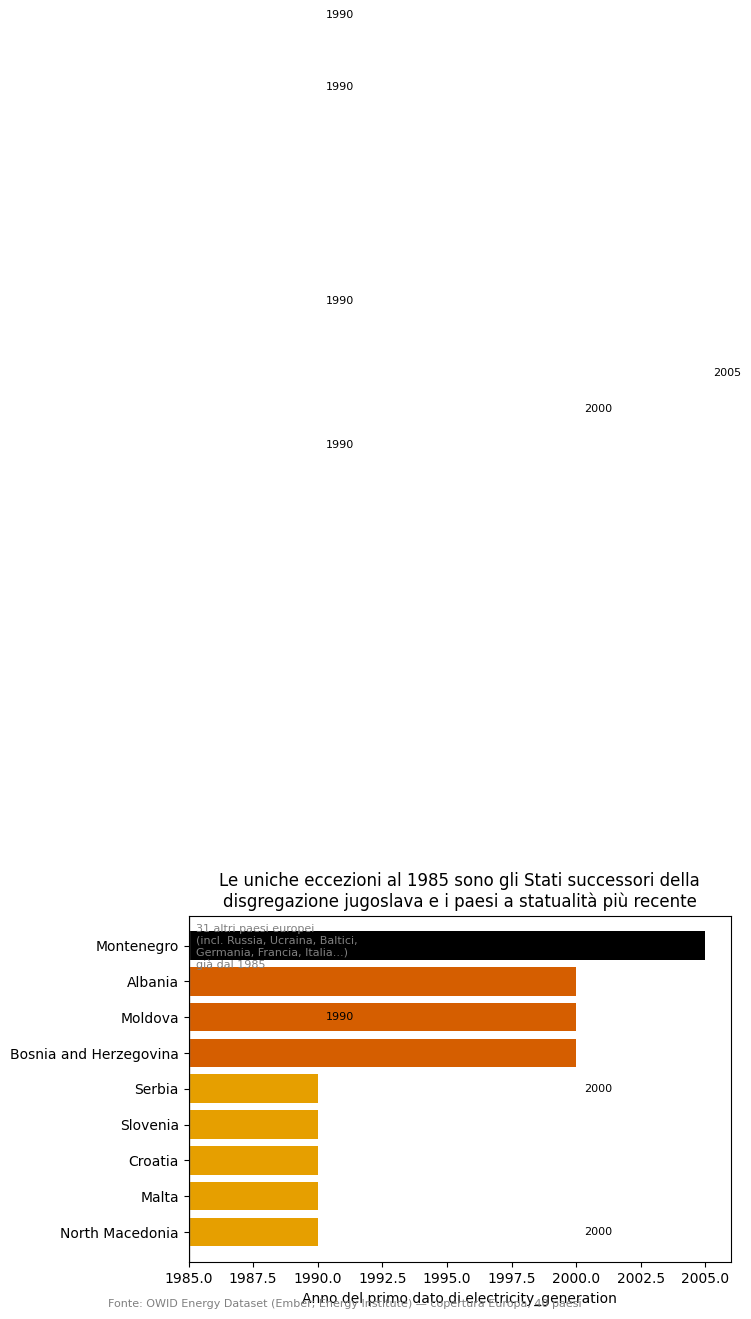

In [11]:
later = fv[fv["first_valid"] > 1985].sort_values("first_valid")
_bucket_color = {1990: "#E69F00", 2000: "#D55E00", 2005: "#000000"}
colors = [_bucket_color[y] for y in later["first_valid"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(later["country"], later["first_valid"] - 1985, left=1985, color=colors)
for y, (country, row) in zip(later["first_valid"], later.iterrows()):
    ax.text(row["first_valid"] + 0.3, country, str(row["first_valid"]), va="center", fontsize=8)
ax.axvline(1985, color="gray", linewidth=1)
ax.text(1985.3, len(later) - 0.4,
        "31 altri paesi europei\n(incl. Russia, Ucraina, Baltici,\nGermania, Francia, Italia...)\ngià dal 1985",
        fontsize=8, color="gray", va="top")
ax.set_xlabel("Anno del primo dato di electricity_generation")
ax.set_title("Le uniche eccezioni al 1985 sono gli Stati successori della\ndisgregazione jugoslava e i paesi a statualità più recente")
fig.text(0.01, 0.01, "Fonte: OWID Energy Dataset (Ember; Energy Institute) — copertura Europa, 40 paesi", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 4. Comporre e confrontare il mix elettrico europeo

Questa sezione prototipa i grafici del tema centrale del progetto — il confronto tra fossili, nucleare
e rinnovabili — prima di scriverli in Streamlit. Ogni grafico è scelto a partire dal **task
comunicativo** (confronto, composizione, evoluzione) e non dal tipo di dato, evitando gli anti-pattern
noti (dual axis, asse Y tagliato, palette non leggibili dai daltonici) e usando la gerarchia percettiva
di Cleveland & McGill per scegliere l'encoding più accurato per ogni domanda. I vincoli di copertura
del Cap. 3 (panel bilanciato, cutoff 2022) restano validi qui.

### 4.1 Perché serve un panel bilanciato

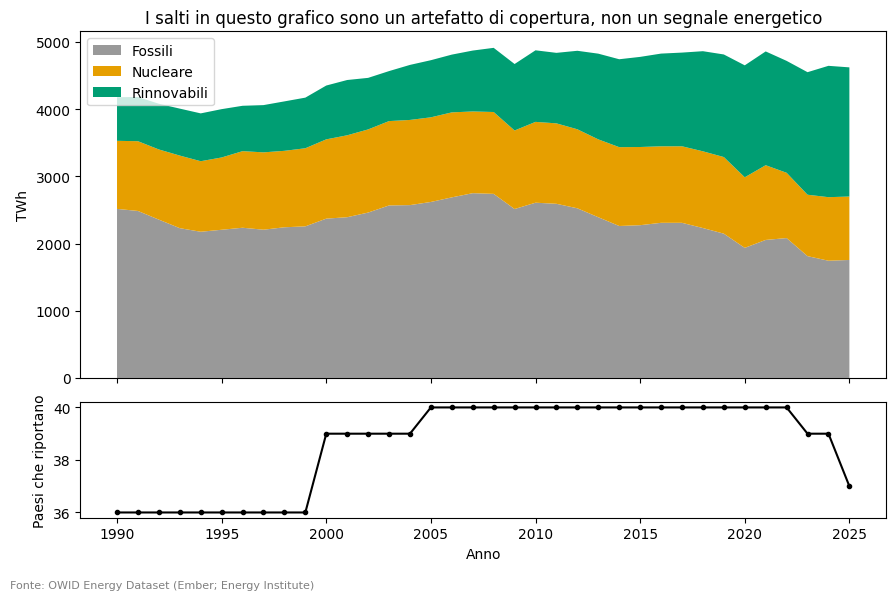

In [12]:
SOURCE_NOTE = "Fonte: OWID Energy Dataset (Ember; Energy Institute)"
PALETTE = {"fossile": "#999999", "nucleare": "#E69F00", "rinnovabili": "#009E73", "calo": "#D55E00"}

agg40 = (
    df_eu[df_eu["year"] >= 1990]
    .groupby("year")[["electricity_generation", "fossil_electricity", "nuclear_electricity", "renewables_electricity"]]
    .sum(min_count=1)
)
agg40["n_countries"] = (
    df_eu[df_eu["year"] >= 1990]
    .groupby("year")["electricity_generation"]
    .apply(lambda s: s.notna().sum())
)

# Due assi allineati (small multiples), non un dual axis sullo stesso plot:
# TWh e "numero di paesi" non condividono un'unità, sovrapporli sarebbe l'anti-pattern
# "dual axis" segnalato nel materiale del corso.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, height_ratios=[3, 1])
ax1.stackplot(
    agg40.index,
    agg40["fossil_electricity"], agg40["nuclear_electricity"], agg40["renewables_electricity"],
    labels=["Fossili", "Nucleare", "Rinnovabili"],
    colors=[PALETTE["fossile"], PALETTE["nucleare"], PALETTE["rinnovabili"]],
)
ax1.set_title("I salti in questo grafico sono un artefatto di copertura, non un segnale energetico")
ax1.set_ylabel("TWh")
ax1.legend(loc="upper left")

ax2.plot(agg40.index, agg40["n_countries"], color="black", marker=".")
ax2.set_ylabel("Paesi che riportano")
ax2.set_xlabel("Anno")

fig.text(0.01, 0.01, SOURCE_NOTE, fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

Il pannello inferiore mostra la causa: il numero di paesi che contribuiscono alla somma passa da 36
(1990–99) a 39 (dal 2000) a 40 (dal ~2005), per poi scendere a 39 e 37 nel 2023–25 per il
right-censoring di Ucraina, Albania e Islanda (Cap. 3.3). Qui evitiamo deliberatamente un **dual axis**
(l'anti-pattern del corso: due unità diverse sullo stesso grafico "fanno vedere" una correlazione che
non è verificabile) usando invece due assi allineati sulla stessa x — il lettore vede il salto nella
serie e la sua causa senza dover fidarsi di una sovrapposizione arbitraria.

La correzione è restringersi a un **panel bilanciato**: paesi con serie completa 1990–2022 su tutte le
variabili chiave.

In [13]:
window = df_eu[(df_eu["year"] >= 1990) & (df_eu["year"] <= 2022)]

complete_countries = [
    country
    for country, grp in window.groupby("country")
    if grp.set_index("year").reindex(range(1990, 2023))[
        ["electricity_generation", "fossil_electricity", "nuclear_electricity", "renewables_electricity"]
    ].notna().all().all()
]
excluded = sorted(set(df_eu["country"].unique()) - set(complete_countries))
print(f"Paesi con serie completa 1990-2022: {len(complete_countries)} / {df_eu['country'].nunique()}")
print(f"Esclusi: {excluded}")

bal_all = window[window["country"].isin(complete_countries)]

# Quanto pesa l'esclusione? Confronto 2020, con e senza i due paesi esclusi più "estremi"
# (Svizzera: nucleare+idro quasi senza fossile; Islanda: 100% rinnovabile).
y = 2020
full40_y = df_eu[df_eu["year"] == y]
bal33_y = full40_y[full40_y["country"].isin(complete_countries)]

print("\n=== Quota sul totale europeo (media pesata per generazione, 2020) ===")
for label, d in [("40 paesi", full40_y), ("33 paesi (panel bilanciato)", bal33_y)]:
    tot = d["electricity_generation"].sum()
    shares = {k: d[f"{k}_electricity"].sum() / tot * 100 for k in ["fossil", "nuclear", "renewables"]}
    print(f"  {label}: {shares}")

print("\n=== Quota media per paese, non pesata (2020) ===")
for label, d in [("40 paesi", full40_y), ("33 paesi (panel bilanciato)", bal33_y)]:
    m = d[["fossil_share_elec", "nuclear_share_elec", "renewables_share_elec"]].mean()
    print(f"  {label}: {m.round(1).to_dict()}")

Paesi con serie completa 1990-2022: 33 / 40
Esclusi: ['Albania', 'Belarus', 'Bosnia and Herzegovina', 'Iceland', 'Moldova', 'Montenegro', 'Switzerland']

=== Quota sul totale europeo (media pesata per generazione, 2020) ===
  40 paesi: {'fossil': np.float64(41.610908681279476), 'nuclear': np.float64(22.580325781701056), 'renewables': np.float64(35.80876545692362)}
  33 paesi (panel bilanciato): {'fossil': np.float64(41.778459455718284), 'nuclear': np.float64(22.830169847444516), 'renewables': np.float64(35.39137064908388)}

=== Quota media per paese, non pesata (2020) ===
  40 paesi: {'fossil_share_elec': 43.0, 'nuclear_share_elec': 14.2, 'renewables_share_elec': 42.8}
  33 paesi (panel bilanciato): {'fossil_share_elec': 42.7, 'nuclear_share_elec': 16.1, 'renewables_share_elec': 41.2}


I 7 paesi esclusi (Albania, Bielorussia, Bosnia ed Erzegovina, Islanda, Moldova, Montenegro,
Svizzera) includono due casi estremi: la Svizzera (nucleare + idro, quasi zero fossile) e l'Islanda
(100% rinnovabile/geotermico). **L'esclusione non è innocua, ma il suo effetto dipende da come si
aggrega**: sulla quota europea pesata per generazione la differenza è minima (nucleare 22.6% → 22.8%,
rinnovabili 35.8% → 35.4%: la Svizzera e l'Islanda sono economie piccole, pesano poco sulla somma
assoluta). Sulla **media semplice per paese**, invece, l'effetto è più visibile (nucleare 14.2% → 16.1%,
rinnovabili 42.8% → 41.2%): qui ogni paese conta allo stesso modo, e togliere due profili estremi sposta
la media di alcuni punti. **Regola pratica**: per l'andamento aggregato europeo usare il panel bilanciato
con somme pesate (sotto); per confronti *tra* paesi non nascondere mai la selezione, ed eventualmente
permettere di reintrodurre Svizzera/Islanda come casi a parte.

### 4.2 Composizione vs confronto: stesso dato, due grafici

Lo stacked area risponde al task "di cosa è fatto il totale" (composizione). Ma la domanda del
progetto è un **confronto** tra tre andamenti — per quello l'encoding più accurato secondo Cleveland &
McGill è la **posizione su una scala comune** (una linea per fonte, stesso asse 0–100%), non lo
spessore di bande impilate su basi che si spostano. Li mettiamo affiancati per mostrare la differenza.

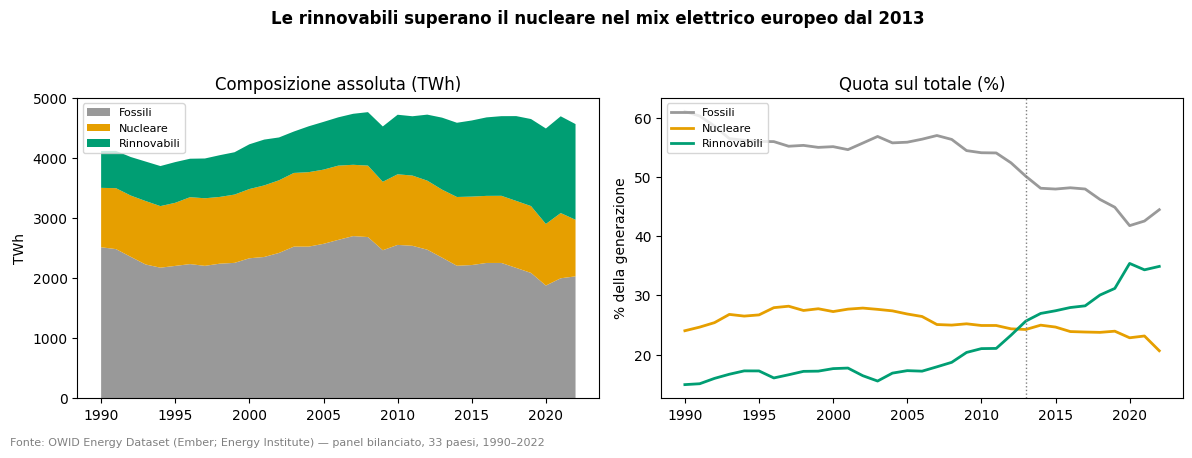

In [14]:
agg_bal = (
    bal_all.groupby("year")[["electricity_generation", "fossil_electricity", "nuclear_electricity", "renewables_electricity"]]
    .sum()
)
agg_bal_share = agg_bal.div(agg_bal["electricity_generation"], axis=0) * 100

crossover = agg_bal_share[agg_bal_share["renewables_electricity"] > agg_bal_share["nuclear_electricity"]].index.min()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].stackplot(
    agg_bal.index,
    agg_bal["fossil_electricity"], agg_bal["nuclear_electricity"], agg_bal["renewables_electricity"],
    labels=["Fossili", "Nucleare", "Rinnovabili"],
    colors=[PALETTE["fossile"], PALETTE["nucleare"], PALETTE["rinnovabili"]],
)
axes[0].set_title("Composizione assoluta (TWh)")
axes[0].set_ylabel("TWh")
axes[0].legend(loc="upper left", fontsize=8)

axes[1].plot(agg_bal_share.index, agg_bal_share["fossil_electricity"], color=PALETTE["fossile"], label="Fossili", linewidth=2)
axes[1].plot(agg_bal_share.index, agg_bal_share["nuclear_electricity"], color=PALETTE["nucleare"], label="Nucleare", linewidth=2)
axes[1].plot(agg_bal_share.index, agg_bal_share["renewables_electricity"], color=PALETTE["rinnovabili"], label="Rinnovabili", linewidth=2)
axes[1].axvline(crossover, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Quota sul totale (%)")
axes[1].set_ylabel("% della generazione")
axes[1].legend(loc="upper left", fontsize=8)

fig.suptitle(f"Le rinnovabili superano il nucleare nel mix elettrico europeo dal {crossover}", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, 33 paesi, 1990–2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

Il pannello di sinistra (composizione) mostra che il totale generato cresce e che i fossili restano il
blocco più grande in volume. Il pannello di destra (confronto) mostra il dato che lo stacked area
nasconde: le rinnovabili superano stabilmente il nucleare a partire dal 2013 (nel 1990 il nucleare
pesava il 24.0% contro il 14.9% delle rinnovabili; nel 2022 il rapporto è invertito, 20.6% contro
34.9%). I fossili scendono dal 61.1% al 44.5% ma restano maggioritari. Nessuna delle due letture è
"sbagliata": rispondono a due domande diverse, ed è per questo che nella dashboard **il tipo di
grafico dovrebbe seguire il task scelto dall'utente**, non essere fisso.

### 4.3 Cinque profili nazionali a confronto

La media europea nasconde traiettorie molto diverse. Scegliamo cinque paesi (nel panel bilanciato)
che rappresentano strategie distinte, verificate sui dati 2022: Francia (nucleare stabile, 63%),
Germania (transizione: fossile ancora dominante ma in calo, nucleare quasi azzerato, rinnovabili in
forte crescita), Polonia (fossile dominante, 79%, transizione appena iniziata), Danimarca (rinnovabili
leader, 81%, trainate dall'eolico), Italia (fossile ancora maggioritario ma in calo costante — 84%→64%
—, nessun nucleare dal referendum del 1987, rinnovabili quasi raddoppiate in quota, 16%→36%). Small
multiples con **assi condivisi** (0–100%) per permettere il confronto diretto tra pannelli —
l'antidoto del corso al dual axis quando si vogliono confrontare più serie.

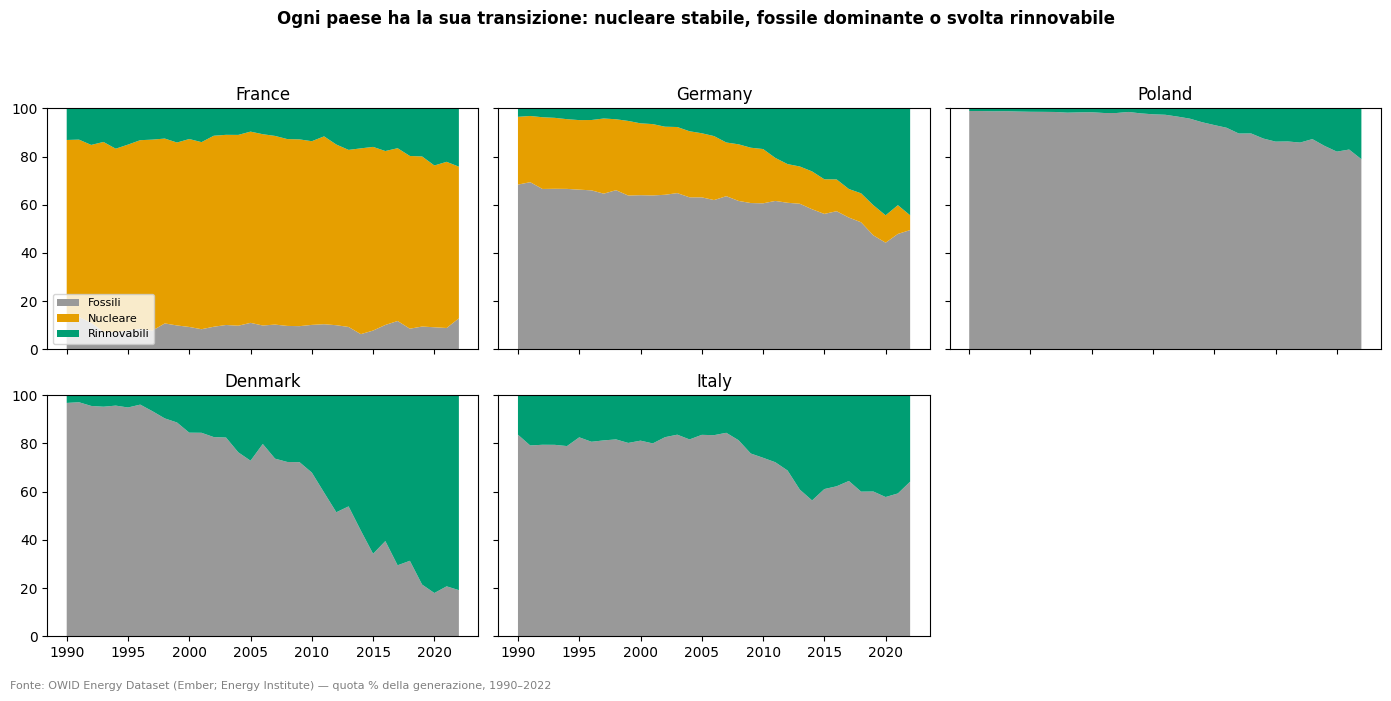

In [15]:
countries_profile = ["France", "Germany", "Poland", "Denmark", "Italy"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, country in zip(axes.flat, countries_profile):
    d = bal_all[bal_all["country"] == country].sort_values("year")
    ax.stackplot(
        d["year"], d["fossil_share_elec"], d["nuclear_share_elec"], d["renewables_share_elec"],
        colors=[PALETTE["fossile"], PALETTE["nucleare"], PALETTE["rinnovabili"]],
        labels=["Fossili", "Nucleare", "Rinnovabili"],
    )
    ax.set_title(country)
    ax.set_ylim(0, 100)
axes.flat[-1].axis("off")  # sesto riquadro inutilizzato (5 paesi su una griglia 2x3)
axes[0, 0].legend(loc="lower left", fontsize=8)
fig.suptitle("Ogni paese ha la sua transizione: nucleare stabile, fossile dominante o svolta rinnovabile", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — quota % della generazione, 1990–2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

La Germania è il caso più interessante per la dashboard: nel 1990 il mix era 68% fossile / 28%
nucleare / 3.5% rinnovabili, nel 2022 è 49.5% / 6.1% / 44.4% — il nucleare non è stato sostituito dalle
rinnovabili ma da un mix di rinnovabili in crescita e fossile ancora dominante (l'"Energiewende" è
un caso da segnalare esplicitamente in dashboard, perché il calo del nucleare tedesco spesso viene
letto — erroneamente — come prova che "le rinnovabili hanno sostituito il nucleare in Europa", mentre
è un pattern specifico di un singolo paese). L'Italia mostra un quinto percorso, più lineare: nessun
nucleare da confrontare (uscita completa dopo il referendum del 1987, quota già a 0 nel 1990), quindi
tutta la transizione passa dalla sostituzione diretta fossile→rinnovabili — dall'84% al 64% di fossile,
dal 16% al 36% di rinnovabili, senza la complessità aggiuntiva del caso tedesco.

### 4.4 Chi ha trasformato di più il proprio mix?

Task di **confronto** puro: un valore per paese (variazione della quota rinnovabili 1990→2022).
Encoding scelto di conseguenza — bar orizzontale, ordinata per valore (non alfabeticamente), colore
diverging per isolare l'unico caso anomalo.

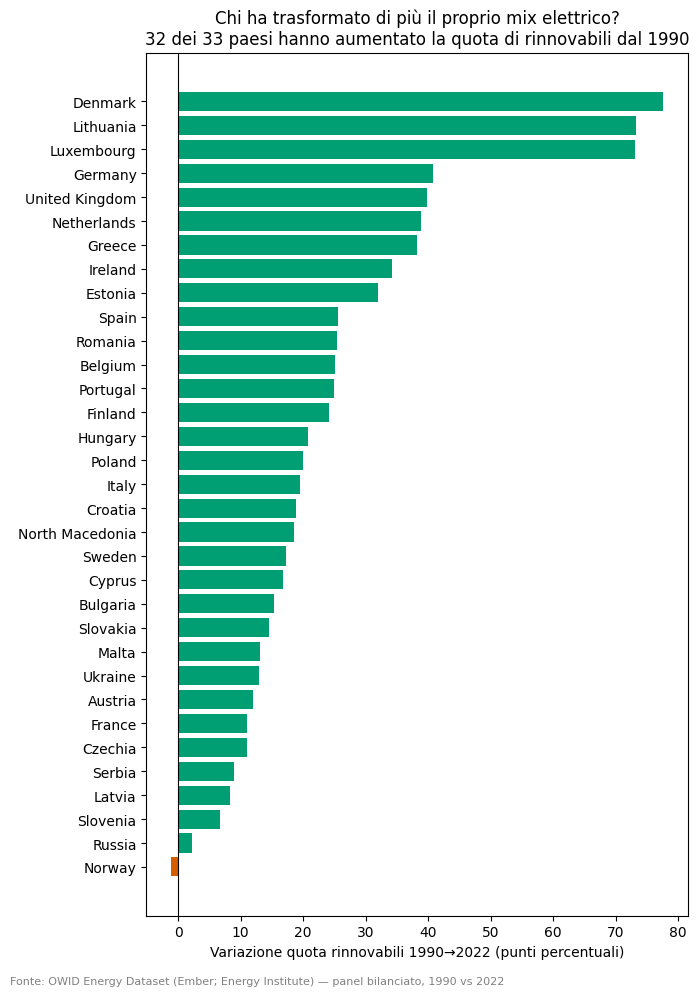

In [16]:
first_last = bal_all[bal_all["year"].isin([1990, 2022])].pivot(
    index="country", columns="year", values="renewables_share_elec"
)
delta = (first_last[2022] - first_last[1990]).sort_values()

colors = [PALETTE["calo"] if v < 0 else PALETTE["rinnovabili"] for v in delta]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(delta.index, delta.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Variazione quota rinnovabili 1990→2022 (punti percentuali)")
ax.set_title(
    f"Chi ha trasformato di più il proprio mix elettrico?\n"
    f"{(delta > 0).sum()} dei {len(delta)} paesi hanno aumentato la quota di rinnovabili dal 1990"
)
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, 1990 vs 2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

Danimarca, Lituania e Lussemburgo guidano la classifica (+73–78 punti). Il solo caso in calo è la
**Norvegia** (-1.1 punti): non è una regressione, è un **effetto soffitto** — era già al 99.8% nel
1990 (idroelettrico), quindi non ha margine di crescita. La Francia, invece, mostra una variazione
modesta (+11 punti) non perché sia rimasta ferma, ma perché nel 1990 partiva già da un mix a basse
emissioni grazie al nucleare: la metrica "variazione quota rinnovabili" penalizza chi ha scelto una
strada diversa (nucleare anziché rinnovabili) per lo stesso obiettivo di decarbonizzazione. Va
dichiarato in dashboard, altrimenti il grafico suggerisce implicitamente che la Francia abbia fatto
"poco", quando ha semplicemente seguito un altro percorso.

### 4.5 Quanto veloce, non solo quanto: un indice di crescita (1990 = 100)

I paragrafi precedenti confrontano **livelli** (quote, TWh). Un'altra domanda utile in dashboard è
quanto velocemente sta cambiando ogni paese — a prescindere dal punto di partenza. La tecnica è la
stessa vista nell'esempio del corso in `altri_file/elaborato_airbnb/pages/2_Trend.py` (*price index*,
base 100 = primo anno): normalizzare rimuove l'effetto del livello iniziale e isola la velocità
relativa. La applichiamo alla produzione rinnovabile assoluta (TWh) dei quattro profili di 4.3,
affiancata al valore assoluto per non perdere la scala reale.

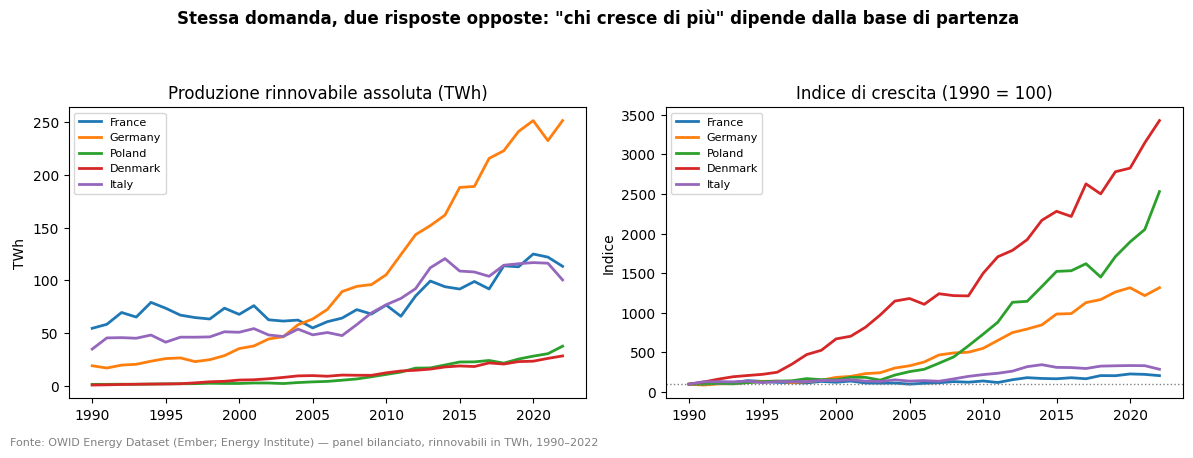

      France  Germany  Poland  Denmark  Italy
year                                         
1990   100.0    100.0   100.0    100.0  100.0
2000   124.0    185.0   156.0    671.0  146.0
2010   140.0    552.0   730.0   1498.0  221.0
2022   208.0   1317.0  2530.0   3425.0  288.0


In [17]:
idx_series = {}
for country in countries_profile:
    s = bal_all[bal_all["country"] == country].sort_values("year").set_index("year")["renewables_electricity"]
    idx_series[country] = s / s.loc[1990] * 100
idx_df = pd.DataFrame(idx_series)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for country in countries_profile:
    s = bal_all[bal_all["country"] == country].sort_values("year").set_index("year")["renewables_electricity"]
    axes[0].plot(s.index, s.values, label=country, linewidth=2)
axes[0].set_title("Produzione rinnovabile assoluta (TWh)")
axes[0].set_ylabel("TWh")
axes[0].legend(fontsize=8)

for country in countries_profile:
    axes[1].plot(idx_df.index, idx_df[country], label=country, linewidth=2)
axes[1].axhline(100, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Indice di crescita (1990 = 100)")
axes[1].set_ylabel("Indice")
axes[1].legend(fontsize=8)

fig.suptitle('Stessa domanda, due risposte opposte: "chi cresce di più" dipende dalla base di partenza', fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, rinnovabili in TWh, 1990–2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

print(idx_df.loc[[1990, 2000, 2010, 2022]].round(0))

Il pannello destro mostra il limite della tecnica quando le basi di partenza differiscono di ordini
di grandezza. Danimarca partiva da 0.83 TWh di rinnovabili nel 1990 e Polonia da 1.49 TWh: quote
quasi nulle che fanno esplodere l'indice (rispettivamente **~3425 e ~2530 nel 2022**), pur avendo
aggiunto molto meno in valore assoluto della Germania, che parte da una base già dieci volte più alta
(19 TWh) e arriva comunque a un indice di **~1317** — "solo" perché la sua base iniziale non era
vicina allo zero. L'Italia, che partiva da una base già consistente (35 TWh, quasi il doppio della
Germania), cresce in modo molto più lineare: indice **~288 nel 2022**, il più contenuto dei cinque
profili — non perché la crescita in TWh sia stata piccola (+65 TWh), ma perché la base di partenza era
già alta. Il pannello sinistro (valori assoluti) restituisce infatti la lettura opposta: la Germania ha
aggiunto ~232 TWh di rinnovabili tra il 1990 e il 2022, più dell'intera generazione elettrica danese di
oggi. Nell'esempio del corso il price index funzionava bene da solo perché i prezzi di partenza delle
città erano vicini (107–152 €, meno di un ordine di grandezza); qui **l'indice va sempre affiancato al
valore assoluto**, mai mostrato da solo, altrimenti Danimarca e Polonia sembrano i casi più dinamici e
l'Italia il più fermo, quando in TWh aggiunti il vero traino resta la Germania e l'Italia è tutt'altro
che ferma.

### 4.6 Chi sostituisce chi: le rinnovabili al posto del fossile o del nucleare?

Il caso tedesco (4.3) solleva una domanda che vale per l'intero panel, non solo per un paese: quando
le rinnovabili crescono, a scapito di quale fonte? Task di **correlazione tra due variazioni** — la
Germania da sola è un aneddoto, i 33 paesi del panel permettono di verificare se il suo pattern è la
regola o l'eccezione. Encoding scelto di conseguenza: uno scatter (posizione su due assi), l'unico
che secondo Cleveland & McGill rappresenta accuratamente una relazione tra due variabili continue.

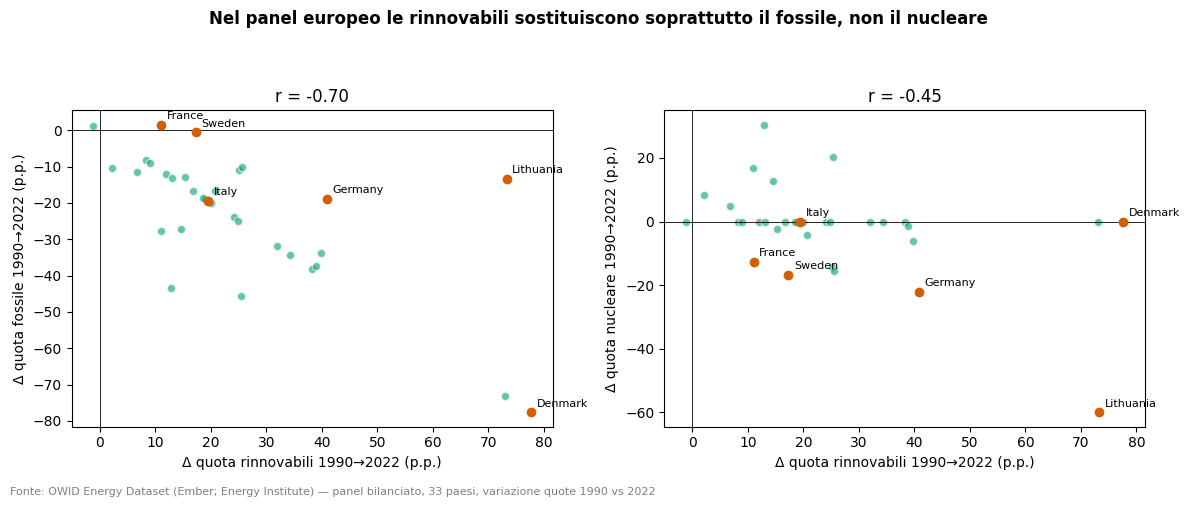

corr(Δrinnovabili, Δfossile)  = -0.70
corr(Δrinnovabili, Δnucleare) = -0.45


In [18]:
first_last_all = bal_all[bal_all["year"].isin([1990, 2022])].pivot_table(
    index="country", columns="year",
    values=["fossil_share_elec", "nuclear_share_elec", "renewables_share_elec"],
)
d_renew = first_last_all["renewables_share_elec"][2022] - first_last_all["renewables_share_elec"][1990]
d_fossil = first_last_all["fossil_share_elec"][2022] - first_last_all["fossil_share_elec"][1990]
d_nuclear = first_last_all["nuclear_share_elec"][2022] - first_last_all["nuclear_share_elec"][1990]

corr_fossil = d_renew.corr(d_fossil)
corr_nuclear = d_renew.corr(d_nuclear)

highlight = ["Germany", "Lithuania", "Denmark", "France", "Sweden", "Italy"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, d_other, label, corr in [
    (axes[0], d_fossil, "fossile", corr_fossil),
    (axes[1], d_nuclear, "nucleare", corr_nuclear),
]:
    ax.scatter(d_renew, d_other, color=PALETTE["rinnovabili"], alpha=0.6, edgecolor="white")
    for c in highlight:
        ax.scatter(d_renew[c], d_other[c], color=PALETTE["calo"], zorder=3)
        ax.annotate(c, (d_renew[c], d_other[c]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlabel("Δ quota rinnovabili 1990→2022 (p.p.)")
    ax.set_ylabel(f"Δ quota {label} 1990→2022 (p.p.)")
    ax.set_title(f"r = {corr:.2f}")

fig.suptitle("Nel panel europeo le rinnovabili sostituiscono soprattutto il fossile, non il nucleare", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, 33 paesi, variazione quote 1990 vs 2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

print(f"corr(Δrinnovabili, Δfossile)  = {corr_fossil:.2f}")
print(f"corr(Δrinnovabili, Δnucleare) = {corr_nuclear:.2f}")

La correlazione conferma che il fossile è il bersaglio prevalente della sostituzione (**r = -0.70**)
più del nucleare (**r = -0.45**): nella maggioranza dei 33 paesi il nucleare non è mai stato presente
(quota 0 sia nel 1990 sia nel 2022 — Danimarca, Grecia, Irlanda, Portogallo, **Italia**, tra gli altri)
o è rimasto stabile, e la crescita delle rinnovabili ha eroso quota fossile. L'Italia è un punto
tipico di questo gruppo maggioritario: +19.5 p.p. di rinnovabili, quasi esattamente speculare ai -19.5
p.p. di fossile, variazione nucleare nulla per assenza strutturale della fonte. Un piccolo gruppo —
Germania, Lituania, Svezia, e in misura minore Francia e Belgio — è però l'eccezione in cui un calo di
nucleare *coesiste* con la crescita rinnovabile, per ragioni specifiche e diverse: la Lituania ha
chiuso la centrale di Ignalina (eredità sovietica) come condizione di adesione all'UE, la Svezia ha
ridotto gradualmente la sua flotta per scelta energetica interna, la Germania ha deciso l'uscita dal
nucleare dopo Fukushima (2011). Il pattern tedesco di 4.3 non è quindi un'anomalia isolata, ma nemmeno
la norma: è uno dei pochi casi in cui "le rinnovabili hanno sostituito il nucleare" è vero — per la
maggior parte degli altri paesi del panel, Italia inclusa, è il fossile, non il nucleare, ad aver
ceduto terreno.

### 4.7 L'indicatore che conta davvero: l'intensità di carbonio

Le quote di mix rispondono alla domanda "di cosa è fatta l'elettricità", ma nucleare e rinnovabili
sono entrambe fonti a basse emissioni: un paese può ridurre la quota nucleare aumentando le
rinnovabili senza migliorare — o persino peggiorando — il proprio bilancio emissivo reale, se la
differenza nel frattempo viene coperta da fossile (il caso tedesco di 4.3). La colonna
`carbon_intensity_elec` (gCO₂eq/kWh) misura l'esito, non la composizione, ed è la metrica su cui vale
la pena chiudere il capitolo.

In [19]:
# Prima versione (naive): media pesata per generazione, senza controllare i NaN di carbon_intensity_elec
agg_ci_naive = bal_all.groupby("year").apply(
    lambda g: (g["carbon_intensity_elec"] * g["electricity_generation"]).sum() / g["electricity_generation"].sum()
)
print(agg_ci_naive.loc[[1990, 1995, 2000, 2010, 2020, 2022]].round(0))

year
1990    356.0
1995    345.0
2000    428.0
2010    397.0
2020    296.0
2022    320.0
dtype: float64

Il numero sembra dire che l'intensità di carbonio sia **aumentata** tra il 1990 e il 2000 (356 → 428
gCO₂/kWh) prima di scendere — in contraddizione con la storia di decarbonizzazione raccontata finora.
Ma è un artefatto della stessa famiglia di problemi vista nel Cap. 3: `carbon_intensity_elec` ha
valori mancanti che questo calcolo non gestisce correttamente. La Russia — generazione tra le
maggiori del panel — non ha `carbon_intensity_elec` per il 1990-1999 (10 anni): la sua produzione
resta al denominatore ma le sue emissioni escono dal numeratore proprio in quegli anni, abbassando
artificialmente la media nel periodo iniziale. La correzione è escludere dal calcolo, anno per anno,
le righe senza `carbon_intensity_elec` — numeratore **e** denominatore insieme, non solo il
numeratore.

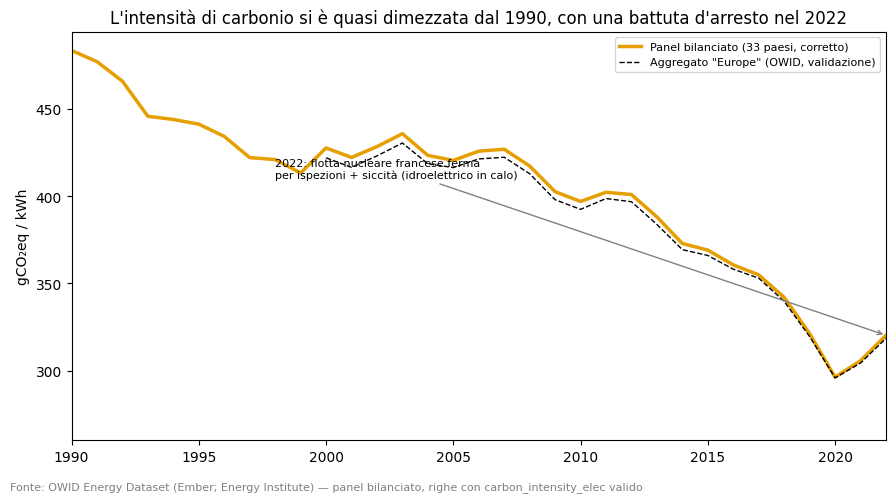

year
1990    483.0
1995    441.0
2000    428.0
2010    397.0
2020    296.0
2022    320.0
dtype: float64


In [20]:
bal_ci = bal_all[bal_all["carbon_intensity_elec"].notna()]

agg_ci = bal_ci.groupby("year").apply(
    lambda g: (g["carbon_intensity_elec"] * g["electricity_generation"]).sum() / g["electricity_generation"].sum()
)

# Validazione: confronto con l'aggregato "Europe" pubblicato direttamente da OWID (non il nostro panel)
eu_owid = df[df["country"] == "Europe"].set_index("year")["carbon_intensity_elec"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(agg_ci.index, agg_ci.values, color=PALETTE["nucleare"], linewidth=2.5, label="Panel bilanciato (33 paesi, corretto)")
ax.plot(eu_owid.index, eu_owid.values, color="black", linewidth=1, linestyle="--", label='Aggregato "Europe" (OWID, validazione)')
ax.annotate(
    "2022: flotta nucleare francese ferma\nper ispezioni + siccità (idroelettrico in calo)",
    xy=(2022, agg_ci.loc[2022]), xytext=(1998, agg_ci.loc[2022] + 90),
    arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8,
)
ax.set_xlim(1990, 2022)
ax.set_ylabel("gCO₂eq / kWh")
ax.set_title("L'intensità di carbonio si è quasi dimezzata dal 1990, con una battuta d'arresto nel 2022")
ax.legend(fontsize=8, loc="upper right")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, righe con carbon_intensity_elec valido", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

print(agg_ci.loc[[1990, 1995, 2000, 2010, 2020, 2022]].round(0))

Una volta corretto, il quadro torna coerente con il resto del capitolo: l'intensità di carbonio del
panel scende in modo pressoché continuo da **483 gCO₂/kWh (1990) a 296 (2020)** — quasi dimezzata —
validata dal confronto con l'aggregato "Europe" pubblicato direttamente da OWID (che parte solo dal
2000 ma coincide entro l'1-2%: 422 contro i nostri 428 nel 2000, 296 contro 296 nel 2020, 318 contro
320 nel 2022). L'unica interruzione è il **2022** (296 → 320): non un'inversione di tendenza ma uno
shock di un solo anno — la produzione nucleare francese è scesa da 379 a 295 TWh (**-22%**) per le
ispezioni sulla corrosione da stress dei reattori, mentre la siccità ha ridotto l'idroelettrico nel
panel; la differenza è stata coperta da fossile. Va segnalato esplicitamente in dashboard: il 2022 è
anche l'anno di cutoff del panel bilanciato (4.1), quindi un grafico di questo tipo rischia di
chiudere su un punto anomalo se non annotato — lo stesso principio del right-censoring del Cap. 3.3,
qui applicato all'ultimo anno anziché al primo.

### 4.8 Il declino del nucleare: picco, evento, crollo

Il Cap. 4.6 ha isolato un piccolo gruppo di paesi dove il calo del nucleare *coincide* con la crescita rinnovabile: Germania, Lituania, Svezia, Francia e Belgio. Per ciascuno la domanda naturale è **quando** è iniziato il declino e **perché** — non solo quanto è cambiata la quota. Task di confronto nel tempo con eventi noti: una linea per paese con un punto sul picco storico e un'annotazione sull'evento che ha innescato la discesa, lo stesso principio già usato in 4.7 per il 2022 francese. Usiamo la serie estesa dal 1985 (non il solo panel bilanciato 1990-2022), perché per Belgio e Lituania il picco storico cade proprio a ridosso di quella soglia.

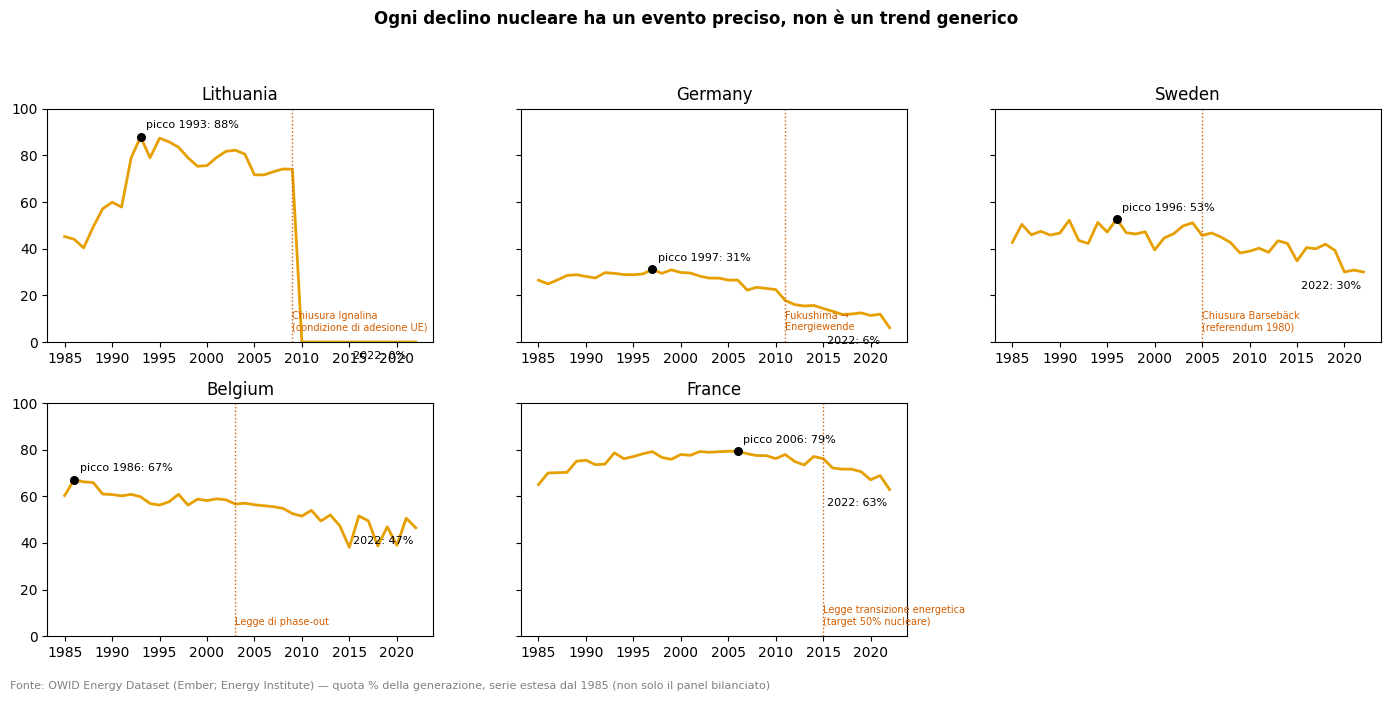

In [21]:
nuclear_countries = ["Lithuania", "Germany", "Sweden", "Belgium", "France"]
events = {
    "Lithuania": (2009, "Chiusura Ignalina\n(condizione di adesione UE)"),
    "Germany": (2011, "Fukushima →\nEnergiewende"),
    "Sweden": (2005, "Chiusura Barsebäck\n(referendum 1980)"),
    "Belgium": (2003, "Legge di phase-out"),
    "France": (2015, "Legge transizione energetica\n(target 50% nucleare)"),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, country in zip(axes.flat, nuclear_countries):
    s = df_eu[df_eu["country"] == country].sort_values("year").set_index("year")["nuclear_share_elec"].dropna()
    s = s[s.index <= 2022]
    peak_year = s.idxmax()
    ax.plot(s.index, s.values, color=PALETTE["nucleare"], linewidth=2)
    ax.scatter([peak_year], [s[peak_year]], color="black", zorder=3, s=30)
    ax.annotate(f"picco {peak_year}: {s[peak_year]:.0f}%", (peak_year, s[peak_year]),
                fontsize=8, xytext=(4, 6), textcoords="offset points")
    ev_year, ev_label = events[country]
    ax.axvline(ev_year, color=PALETTE["calo"], linestyle=":", linewidth=1)
    ax.annotate(ev_label, (ev_year, 5), fontsize=7, color=PALETTE["calo"])
    ax.annotate(f"2022: {s.loc[2022]:.0f}%", (2022, s.loc[2022]), fontsize=8,
                xytext=(-45, -12), textcoords="offset points")
    ax.set_title(country)
    ax.set_ylim(0, 100)
axes.flat[-1].axis("off")
fig.suptitle("Ogni declino nucleare ha un evento preciso, non è un trend generico", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — quota % della generazione, serie estesa dal 1985 (non solo il panel bilanciato)", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

Il picco e l'evento non coincidono mai: la Lituania tocca l'88% nel 1993 (Ignalina, eredità sovietica, unica centrale del paese) ma il declino a zero avviene solo dopo la chiusura definitiva del secondo reattore nel 2009, imposta come condizione di adesione all'UE — sedici anni dopo il picco. La Germania picca al 31.2% nel 1997, ben prima di Fukushima (2011): l'uscita dal nucleare non è la causa del declino ma la sua accelerazione — l'ultimo reattore si è fermato nell'aprile 2023, pochi mesi dopo il 2022 con cui chiude questo pannello. Svezia e Belgio mostrano il pattern più lento: entrambi i declini seguono leggi di phase-out (Svezia dopo il referendum del 1980, chiusure Barsebäck 1999 e 2005; Belgio con la legge del 2003) ma restano rispettivamente al 30% e al 46.5% ancora nel 2022 — un phase-out annunciato non è un crollo immediato. La Francia, infine, è il caso più lento di tutti: picca nel 2006 (79.4%) e nel 2022 è ancora al 62.9%, nonostante la legge del 2015 avesse fissato un obiettivo del 50% mai raggiunto — il calo puntuale del 2022 (già discusso in 4.7) è dovuto a un evento congiunturale (corrosione, siccità), non alla legge.

### 4.9 Fossile e intensità di carbonio: la correlazione attesa, resa esplicita

Il Cap. 4.7 ha corretto la media pesata di `carbon_intensity_elec`, ma non ha ancora mostrato *perché* quella colonna sia l'indicatore giusto: la quota fossile e l'intensità di carbonio dovrebbero muoversi quasi insieme per definizione. Verificarlo è un task di correlazione tra due variabili continue — lo stesso encoding di 4.6, uno scatter — sul panel bilanciato, ultimo anno disponibile (2022).

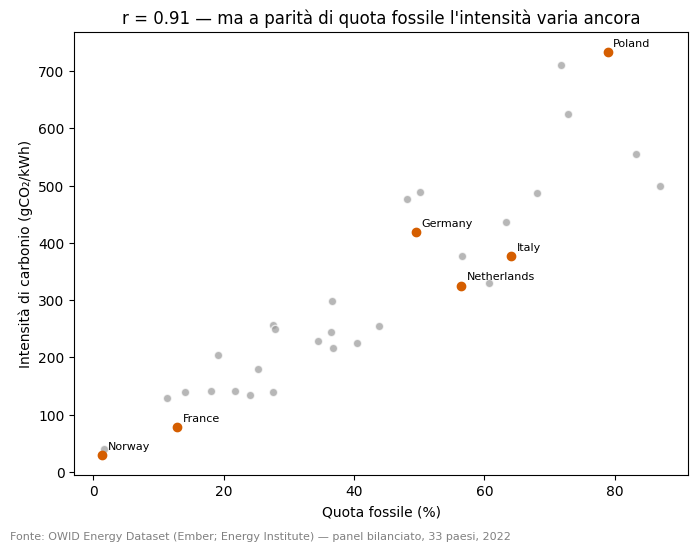

corr(fossil_share_elec, carbon_intensity_elec), 2022: 0.912


In [22]:
y2022 = bal_ci[bal_ci["year"] == 2022]
corr_fc = y2022["fossil_share_elec"].corr(y2022["carbon_intensity_elec"])

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(y2022["fossil_share_elec"], y2022["carbon_intensity_elec"], color=PALETTE["fossile"], alpha=0.7, edgecolor="white")
for c in ["Germany", "Netherlands", "Poland", "Norway", "France", "Italy"]:
    row = y2022[y2022["country"] == c]
    if not row.empty:
        ax.scatter(row["fossil_share_elec"], row["carbon_intensity_elec"], color=PALETTE["calo"], zorder=3)
        ax.annotate(c, (row["fossil_share_elec"].iloc[0], row["carbon_intensity_elec"].iloc[0]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Quota fossile (%)")
ax.set_ylabel("Intensità di carbonio (gCO₂/kWh)")
ax.set_title(f"r = {corr_fc:.2f} — ma a parità di quota fossile l'intensità varia ancora")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, 33 paesi, 2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

print(f"corr(fossil_share_elec, carbon_intensity_elec), 2022: {corr_fc:.3f}")

La correlazione è fortissima (**r = 0.91**): la quota fossile spiega la quasi totalità della varianza dell'intensità di carbonio, confermando che le due metriche raccontano la stessa storia da due angolazioni diverse. Ma **non sono intercambiabili**: Germania (49.5% fossile, 420 gCO₂/kWh) e Paesi Bassi (56.4% fossile, 326 gCO₂/kWh) hanno quote fossili simili — la Germania perfino più bassa — ma un'intensità molto diversa, perché il mix fossile non è omogeneo: il carbone (in particolare la lignite tedesca) emette più del gas naturale (dominante nel mix olandese) a parità di quota di generazione. La quota fossile dice *quanto* fossile c'è; l'intensità di carbonio dice *quanto inquina* quel fossile — la seconda resta la metrica da preferire quando l'obiettivo è confrontare l'esito emissivo, non solo la composizione del mix (coerente con la sintesi di 4.7).

### 4.10 Chart critique: perché non un radar chart

I cinque profili di 4.3 invitano a un confronto multi-dimensionale (fossile, nucleare, idro, eolico, solare, altre rinnovabili): la tentazione grafica classica è un **radar chart** ("un poligono per paese"). Lo costruiamo qui apposta per mostrarne il limite, con lo stesso spirito critico di 4.1 (dual axis) e del Cap. 3: un cattivo grafico va mostrato e spiegato, non solo evitato in silenzio.

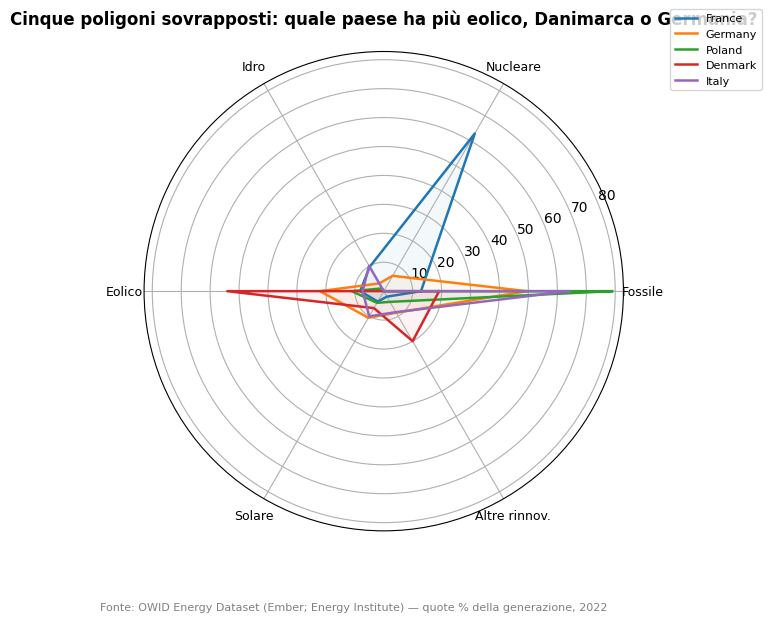

In [23]:
import numpy as np

radar_cols = ["fossil_share_elec", "nuclear_share_elec", "hydro_share_elec",
              "wind_share_elec", "solar_share_elec", "other_renewables_share_elec"]
radar_labels = ["Fossile", "Nucleare", "Idro", "Eolico", "Solare", "Altre rinnov."]

d2022 = df[(df["country"].isin(countries_profile)) & (df["year"] == 2022)].set_index("country")[radar_cols]

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
for country in countries_profile:
    values = d2022.loc[country].tolist()
    values += values[:1]
    ax.plot(angles, values, label=country, linewidth=1.8)
    ax.fill(angles, values, alpha=0.05)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_title("Cinque poligoni sovrapposti: quale paese ha più eolico, Danimarca o Germania?", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — quote % della generazione, 2022", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

Il radar sovrappone sei poligoni irregolari e costringe a confrontare **angoli e aree** invece che posizioni su un asse comune — l'encoding meno accurato nella gerarchia di Cleveland & McGill, l'opposto della scelta fatta in 4.2 e 4.3. Rispondere a una domanda semplice come "chi ha più eolico, Danimarca o Germania?" richiede di confrontare due segmenti radiali che partono da angoli diversi — impossibile a colpo d'occhio, mentre nel piccolo multiplo di 4.3 (stessa scala 0-100% su tutti i pannelli) la risposta è immediata (Danimarca 54% contro il 22% della Germania). Il radar aggiunge anche una distorsione percettiva propria: l'area di un poligono cresce più che linearmente con i valori sui suoi assi, quindi un paese con valori medi su tutti gli assi può sembrare visivamente "più grande" di un paese con un solo valore dominante, a parità di informazione trasmessa. **Non lo useremo in dashboard**: per un confronto multi-variabile tra pochi paesi restano preferibili i small multiples di 4.3 (stessa scala, posizione lineare) o, in alternativa, uno stacked bar al 100% quando serve un solo pannello.

### 4.11 Sintesi per la dashboard

- **Dati**: panel bilanciato (33 paesi, 1990–2022) come default per confronti nel tempo; Svizzera e
  Islanda selezionabili a parte con avviso esplicito, non nascosti.
- **Tipo di grafico legato al task**, non fisso: stacked area per "composizione", linee su base 0–100%
  per "confronto" tra fonti, bar orizzontale ordinata per "chi ha fatto di più/meno", scatter per
  "correlazione tra due variazioni".
- **Niente dual axis**: quando servono due grandezze non comparabili (es. TWh e numero di paesi), due
  pannelli allineati sulla stessa x, mai due assi Y sullo stesso plot.
- **Indice di crescita (base 100) sempre affiancato al valore assoluto**, mai da solo: quando le basi
  di partenza differiscono di ordini di grandezza (4.5, Danimarca/Polonia da quasi zero rinnovabili
  contro Germania/Italia), l'indice da solo esagera i paesi piccoli e nasconde chi guida in valore
  assoluto.
- **Palette fissa e colorblind-safe** in tutta la dashboard (Okabe-Ito: grigio fossili, arancio
  nucleare, verde rinnovabili, rosso solo per evidenziare un'anomalia/calo).
- **Titoli-messaggio**, non etichette metodologiche, e fonte sempre visibile in calce a ogni grafico.
- **Metriche con contesto obbligatorio**: una classifica di "variazione quota rinnovabili" richiede una
  nota su chi partiva già decarbonizzato con un mix diverso (nucleare) — altrimenti la metrica
  penalizza implicitamente una strategia legittima. Allo stesso modo, "le rinnovabili sostituiscono il
  nucleare" (4.6) vale solo per un piccolo gruppo di paesi (Germania, Lituania, Svezia): per il resto
  del panel, Italia inclusa, il bersaglio della sostituzione è il fossile (r = -0.70 contro r = -0.45).
- **Quota di mix ≠ esito emissivo**: `carbon_intensity_elec` (4.7) va offerto come metrica alternativa
  alle quote, perché nucleare e rinnovabili sono entrambe a basse emissioni — un paese può spostare
  quota da nucleare a rinnovabili senza migliorare il proprio bilancio reale se il fossile copre la
  differenza nel frattempo.
- **Nucleare**: quando si mostra il declino di un paese (Germania, Lituania, Svezia, Belgio, Francia), annotare sempre l'evento politico che lo spiega (4.8) — un trend numerico senza la causa suggerisce un declino "naturale" che non è mai stato tale.
- **Radar chart: mai usarlo per confronti multi-fonte** (4.10) — angolo e area sono l'encoding meno accurato della gerarchia di Cleveland & McGill; usare invece small multiples o stacked bar al 100%.
- **Attenzione ai NaN negli aggregati pesati**: prima di pubblicare una media pesata per generazione,
  verificare che numeratore e denominatore escludano insieme le righe con dato mancante (4.7) — un
  singolo paese grande con una colonna incompleta può alterare l'andamento aggregato di un intero
  decennio.
- **2022 come endpoint va sempre annotato quando anomalo** (nucleare francese ai minimi, siccità): un
  grafico che termina lì senza nota rischia di essere letto come un'inversione di tendenza strutturale.
- Selettore paesi con default suggerito: Francia, Germania, Polonia, Danimarca, **Italia** (cinque
  profili distinti — l'ultimo aggiunto per rilevanza diretta con il pubblico dell'esame), estendibile a
  qualunque paese del panel bilanciato.